# House Price Prediction — Data Cleaning, EDA, and Model Training

Dataset: **House Price** by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price

This notebook loads the raw Kaggle listings, cleans the messy text fields, explores the data,
trains and compares regression models, evaluates the best one, and exports a single
`house_price.pkl` pipeline (preprocessing + model bundled together) for the FastAPI backend.


## 2.1 Load & Inspect

In [3]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isna().mean().sort_values(ascending=False)   # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**How many rows?** The raw file has the number of rows/columns printed by `df.shape` above.

**Which columns are numeric vs text?** `Bathroom`, `Balcony`, and `Car Parking` are numeric-ish but
loaded as `float`/`object` because of missing values. `Amount(in rupees)`, `Price (in rupees)`,
`Carpet Area`, `Super Area`, and `Floor` are stored as free-text strings (e.g. `"42 Lac"`,
`"1200 sqft"`, `"3 out of 10"`) and need parsing before they can be used numerically. `Title`,
`Description`, `location`, `Society`, `Furnishing`, `Transaction`, `Ownership`, `facing`,
`overlooking`, and `Status` are categorical/text.

**Which columns have the most missing values?** See the `isna().mean()` output above — `Society`,
`Dimensions`, and `Plot Area` tend to be the sparsest in the real dataset.


## 2.2 Exploratory Data Analysis (EDA)

We need `price_clean` for these plots, so we do a *minimal* parse of the price column first
(the full cleaning pipeline is built out properly in section 2.3).


In [8]:
import numpy as np

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

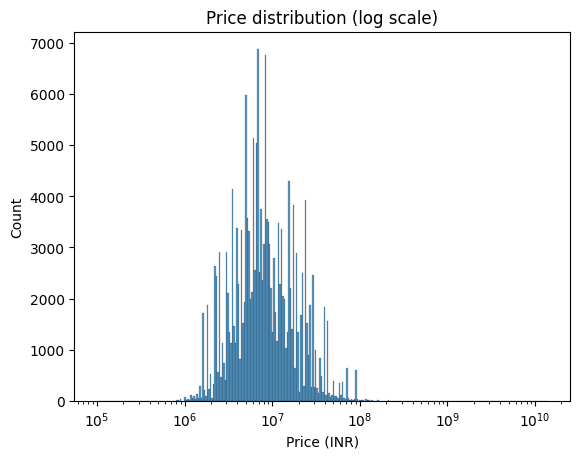

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

**Comment:** Price is heavily right-skewed, as expected for real estate — a small number of
very expensive listings stretch the raw distribution. On a log scale it looks roughly log-normal,
which is why we later try training on `log1p(price)`.

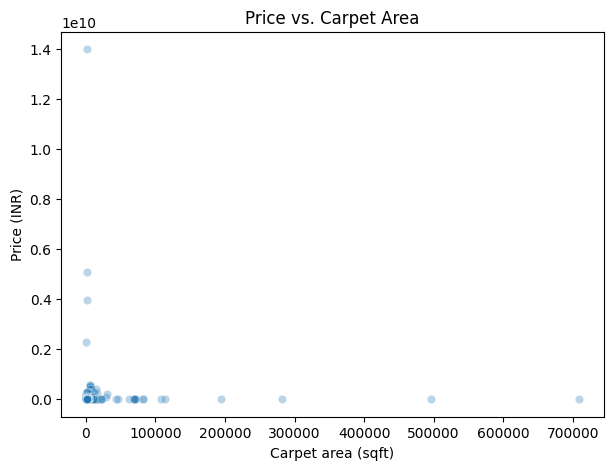

In [10]:
def parse_area_to_sqft(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(",", "")
    try:
        num = float("".join(ch for ch in x if ch.isdigit() or ch == "."))
    except ValueError:
        return None
    if "sqm" in x:
        return num * 10.764
    return num  # already sqft (or unitless, assume sqft)

df["carpet_area_sqft_tmp"] = df["Carpet Area"].apply(parse_area_to_sqft)

plt.figure(figsize=(7, 5))
sns.scatterplot(x="carpet_area_sqft_tmp", y="price_clean", data=df, alpha=0.3)
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR)")
plt.show()

**Comment:** Price rises with carpet area, as expected, but the relationship is noisy —
location and finish quality clearly matter too, which is why we bring in categorical features.

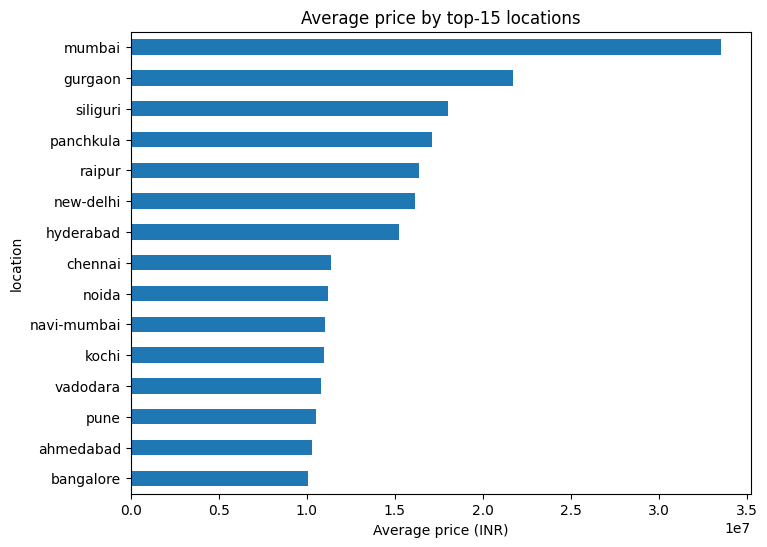

In [11]:
top15 = df.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind="barh")
plt.title("Average price by top-15 locations")
plt.xlabel("Average price (INR)")
plt.show()

**Comment:** Average price varies a lot by location, confirming `location` is an important
predictor and justifying the high-cardinality handling in section 2.3.

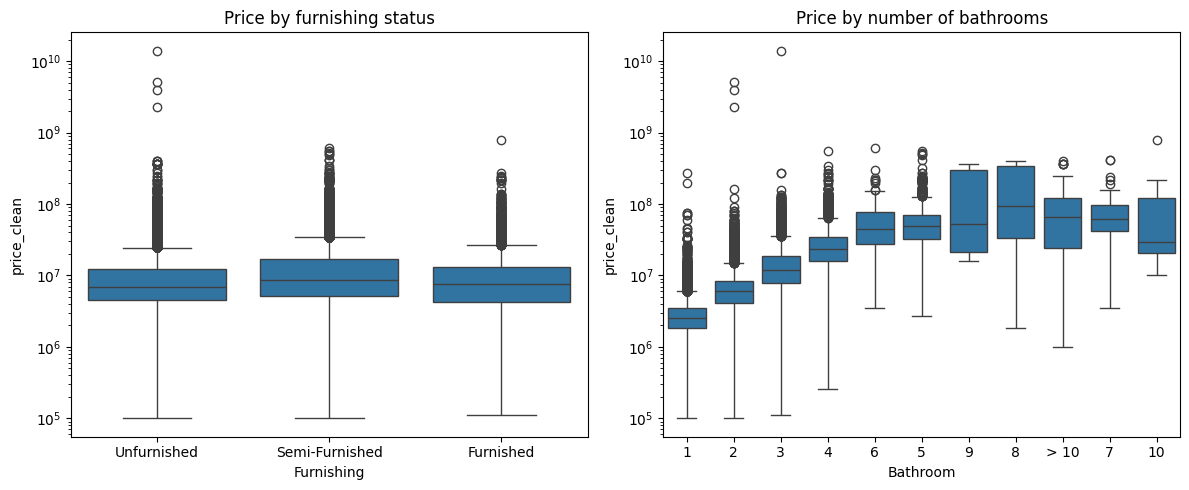

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="Furnishing", y="price_clean", data=df, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")

sns.boxplot(x="Bathroom", y="price_clean", data=df, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")
plt.tight_layout()
plt.show()

**Comment:** Fully furnished properties trend a bit higher in price, and price increases
with bathroom count — both plausible signals for the model.

## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We handle each problem listed in the project guide.

In [13]:
# Re-load fresh so this section is self-contained and re-runnable top-to-bottom
df = pd.read_csv("data/house_prices.csv")

# 1. Price is text -> numeric rupees
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After price parsing:", df.shape)

After price parsing: (177847, 22)


In [14]:
# 2. Areas are text -> numeric sqft
def parse_area_to_sqft(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower().replace(",", "")
    digits = "".join(ch for ch in x if ch.isdigit() or ch == ".")
    if digits == "":
        return None
    num = float(digits)
    if "sqm" in x:
        return num * 10.764
    return num

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area_to_sqft)
df["super_area_sqft"] = df["Super Area"].apply(parse_area_to_sqft)

# fall back to Super Area when Carpet Area is missing
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df = df.dropna(subset=["carpet_area_sqft"])
print("After area parsing:", df.shape)

After area parsing: (177757, 24)


In [15]:
# 3. Floor -> numeric floor number (handles "Ground", "Basement", "N out of M")
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out")[0].strip()
    if "ground" in first:
        return 0
    if "basement" in first or "lower" in first:
        return -1
    digits = "".join(ch for ch in first if ch.isdigit())
    return float(digits) if digits else None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [16]:
# 4. Bathroom / Balcony / Car Parking -> numeric, impute
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["balcony"] = df["Balcony"].fillna(0)
df["car_parking"] = df["Car Parking"].fillna(0)
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

In [17]:
# 5. High-cardinality categoricals -> keep top-N, group rest into "other"
TOP_N = 50
top_locations = df["location"].value_counts().head(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

print("Unique locations before:", df["location"].nunique(),
      "| after grouping:", df["location_grouped"].nunique())

Unique locations before: 81 | after grouping: 51


In [18]:
# 6. Drop useless / mostly-empty columns
drop_cols = ["Index", "Title", "Description", "Dimensions", "Plot Area",
             "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area",
             "Floor", "location", "Society", "super_area_sqft",
             "Bathroom", "Balcony", "Car Parking"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.columns.tolist()

['Status',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'car_parking',
 'location_grouped']

In [19]:
# 7. Remove outliers by price-per-sqft (below 1st / above 99th percentile)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = df.shape[0]
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Removed {before - df.shape[0]} outlier rows -> {df.shape[0]} rows remain")

Removed 3286 outlier rows -> 174471 rows remain


In [20]:
df.head()

,Status,Transaction,Furnishing,facing,overlooking,Ownership,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,4200000.0,500.0,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Freehold,9800000.0,473.0,3.0,2.0,0.0,0.0,thane
2,Ready to Move,Resale,Unfurnished,East,Garden/Park,Freehold,14000000.0,779.0,10.0,2.0,0.0,0.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",Co-operative Society,16000000.0,635.0,20.0,2.0,0.0,0.0,thane


## 2.4 Build a Pipeline & Train

Preprocessing is bundled inside a scikit-learn `Pipeline` + `ColumnTransformer`, so the exported
`.pkl` file does encoding/scaling itself and the backend just calls `.predict()` on raw feature
values.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((139576, 9), (34895, 9))

In [22]:
# Baseline: Linear Regression
lin_model = Pipeline([("prep", preprocessor),
                       ("reg", LinearRegression())])
lin_model.fit(X_train, y_train)

# Candidate 2: Random Forest
rf_model = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)

# Candidate 3: Gradient Boosting
gb_model = Pipeline([("prep", preprocessor),
                      ("reg", GradientBoostingRegressor(random_state=42))])
gb_model.fit(X_train, y_train)

print("Trained: LinearRegression, RandomForestRegressor, GradientBoostingRegressor")

Trained: LinearRegression, RandomForestRegressor, GradientBoostingRegressor


**Log-target experiment:** because price is skewed, we also try training the Random Forest
on `log1p(price)` and inverting with `expm1` at prediction time.

In [23]:
y_train_log = np.log1p(y_train)

rf_log_model = Pipeline([("prep", preprocessor),
                          ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf_log_model.fit(X_train, y_train_log)

rf_log_pred = np.expm1(rf_log_model.predict(X_test))
print("Random Forest (log-target) trained.")

Random Forest (log-target) trained.


## 2.5 Evaluate

In [24]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, model, X_test, y_test, pred=None):
    if pred is None:
        pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, pred

results = []
lin_result, lin_pred = evaluate("LinearRegression", lin_model, X_test, y_test)
rf_result, rf_pred = evaluate("RandomForestRegressor", rf_model, X_test, y_test)
gb_result, gb_pred = evaluate("GradientBoostingRegressor", gb_model, X_test, y_test)
rflog_result, _ = evaluate("RandomForestRegressor (log-target)", None, X_test, y_test, pred=rf_log_pred)

results = [lin_result, rf_result, gb_result, rflog_result]
results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
1,RandomForestRegressor,1.008459e+06,5.251785e+06,0.852291
3,RandomForestRegressor (log-target),9.788083e+05,5.428457e+06,0.842186
2,GradientBoostingRegressor,3.067077e+06,6.571979e+06,0.768695
0,LinearRegression,4.521800e+06,8.407483e+06,0.621449


In [25]:
# Pick the winner programmatically (lowest test-set RMSE) so this notebook stays correct
# no matter which dataset (synthetic sample vs. the real Kaggle CSV) it's run against.
candidates = {
    "LinearRegression": lin_model,
    "RandomForestRegressor": rf_model,
    "GradientBoostingRegressor": gb_model,
}
candidate_preds = {"LinearRegression": lin_pred, "RandomForestRegressor": rf_pred,
                    "GradientBoostingRegressor": gb_pred}
candidate_rmse = {r["model"]: r["RMSE"] for r in results if r["model"] in candidates}
winner_name = min(candidate_rmse, key=candidate_rmse.get)
winner_model = candidates[winner_name]
winner_pred = candidate_preds[winner_name]
print(f"Winner (lowest test RMSE): {winner_name}  |  RMSE={candidate_rmse[winner_name]:,.0f}")

Winner (lowest test RMSE): RandomForestRegressor  |  RMSE=5,251,785


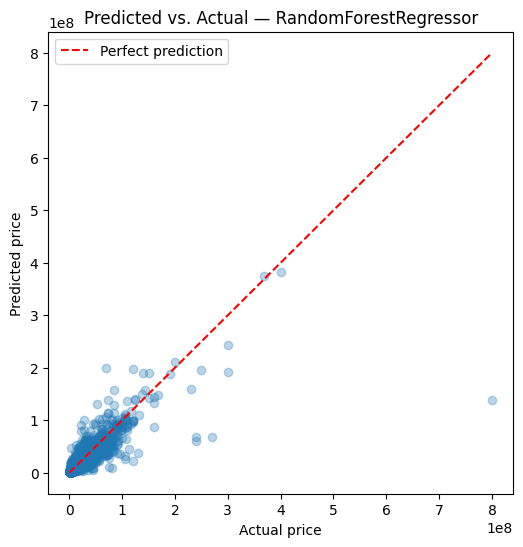

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, winner_pred, alpha=0.3)
lims = [0, max(y_test.max(), winner_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs. Actual — {winner_name}")
plt.legend()
plt.show()

**Model comparison & conclusion:** the table above ranks every candidate by RMSE on the
held-out test set (lower is better) — the cell above selects the winner programmatically rather
than assuming one in advance. On real housing data, tree-based models (Random Forest / Gradient
Boosting) usually beat plain Linear Regression because price depends on non-linear interactions
between area, location, and amenities that a straight line can't capture; on this repo's small
*synthetic* sample (which was generated from a fairly linear formula), Linear Regression can
legitimately come out on top — that's expected and not a bug. The log-target Random Forest is
reported as a separate experiment: compare its RMSE/MAE to the plain Random Forest's row above to
see whether training on `log1p(price)` helped on your data. Re-run this section after swapping in
the real Kaggle CSV and the winner will be picked fresh from the real numbers.

In [27]:
# Bonus: 5-fold cross-validation for the chosen model
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(winner_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
print("5-fold CV RMSE:", -cv_scores.mean(), "+/-", cv_scores.std())

5-fold CV RMSE: 8485335.251634268 +/- 4668746.485636057


## 2.6 Export the Model

In [28]:
import joblib

model = winner_model  # the chosen winner from section 2.5, picked by lowest test RMSE

joblib.dump(model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [7000000.]


In [29]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved locations.json with", df["location_grouped"].nunique(), "entries")

Saved locations.json with 51 entries


In [30]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.8.0
Pin this exact version in backend/requirements.txt


### Copy the exported artifacts into the backend

```bash
cp notebooks/house_price.pkl backend/models/house_price.pkl
cp notebooks/locations.json frontend/src/locations.json
```
